For Fig. 2F and Fig. S3A-E

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(stringr)
    library(Seurat)
    library(dplyr)
    library(tidyverse)
    library(Matrix)
    library(ggpubr)
    
library(showtext)
library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100) 

In [2]:
#load file
WD <- "data/"
sample <- "filtered_counts_SELECTseq_200000.rds"

adata <- readRDS(paste0(WD, sample))
adata

An object of class Seurat 
31360 features across 245 samples within 1 assay 
Active assay: RNA (31360 features, 0 variable features)
 1 layer present: counts

In [3]:
head(adata@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,sample,sample_group,method,cell_line
,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AALYROUH,SeuratProject,7170,2557,U2OS_PIKcrRNA1_9,U2OS_PIKcrRNA1,PIKcrRNA1,U2OS
ABAKTQEY,SeuratProject,3993,2046,U2OS_PIKnocrRNA_44,U2OS_PIKnocrRNA,PIKnocrRNA,U2OS
AKWZQSSD,SeuratProject,5813,2388,U2OS_PIKcrRNA1_31,U2OS_PIKcrRNA1,PIKcrRNA1,U2OS
ALCVWAMH,SeuratProject,5288,1863,U2OS_PIKnocrRNA_48,U2OS_PIKnocrRNA,PIKnocrRNA,U2OS
APLTXKDC,SeuratProject,4344,1423,U2OS_PIKnocrRNA_3,U2OS_PIKnocrRNA,PIKnocrRNA,U2OS
APOVDOUF,SeuratProject,3979,1122,T47D_PIKcrRNA4_18,T47D_PIKcrRNA4,PIKcrRNA4,T47D


In [4]:
unique(adata@meta.data$sample_group)

[1] "U2OS_PIKcrRNA1"  "U2OS_PIKnocrRNA" "T47D_PIKcrRNA4"  "T47D_PIKnocrRNA"
[5] "T47D_PIKcrRNA1"  "U2OS_PIKcrRNA4"

Warning message:
“Duplicated aesthetics after name standardisation: parse”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


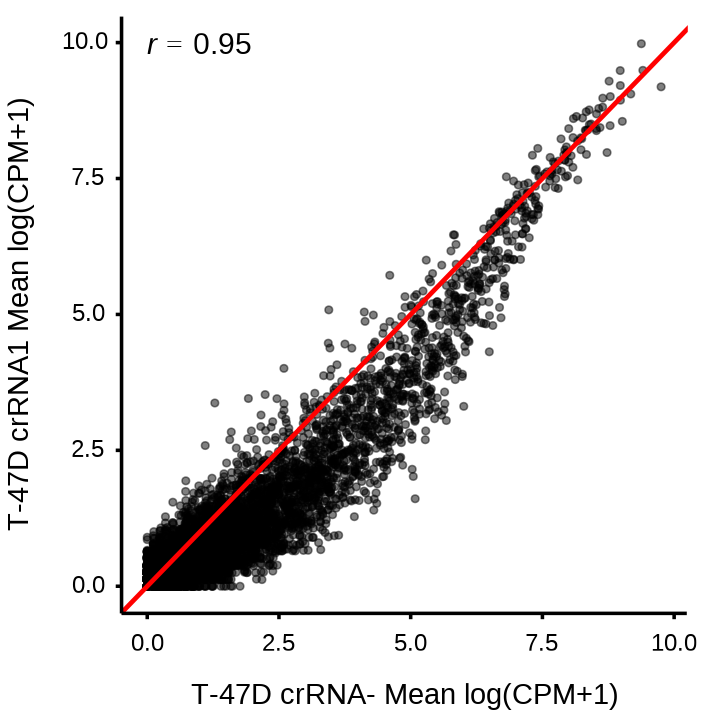

In [5]:
options(repr.plot.width = 6, repr.plot.height =6) 

#input
adataA <- subset(adata, sample_group == "T47D_PIKnocrRNA")
adataB <- subset(adata, sample_group == "T47D_PIKcrRNA1")

#get raw count data
exprA <- data.frame(GetAssayData(adataA, layer = "counts"))

exprB <- data.frame(GetAssayData(adataB, layer = "counts"))


#normalise
for (i in rownames(adataA@meta.data)){
    exprA[, i] <- (exprA[, i]/adataA@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprA[, i] <- log1p(exprA[, i]) #natural log
}

for (i in rownames(adataB@meta.data)){
    exprB[, i] <- (exprB[, i]/adataB@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprB[, i] <- log1p(exprB[, i]) #natural log
}

# Calculate average expression for each gene across cells
mean_exprA <- rowMeans(exprA)
mean_exprB <- rowMeans(exprB)

# Keep only common genes
common_genes <- intersect(rownames(exprA), rownames(exprB))

# Build a data frame
df_cor1 <- data.frame(
  gene = common_genes,
  A = mean_exprA[common_genes],
  B = mean_exprB[common_genes]
)


# Plot mean expression correlation
ggplot(df_cor1, aes(x = A, y = B)) +
  geom_point(alpha = 0.5, color = "black") +                     # scatter points
  stat_cor(
  method = "pearson",
  aes(label = paste0("italic(r) == ", round(after_stat(r), 2))),
  label.x = min(df_cor1$A),
  label.y = max(df_cor1$B),
  size = 8,
  parse = TRUE
) +
  geom_abline(size=1, slope = 1, intercept = 0, linetype = "solid",    # optional y=x line
              color = "red") +
  theme_bw(base_size = 14) +
  labs(
    x = "T-47D crRNA- Mean log(CPM+1)",
    y = "T-47D crRNA1 Mean log(CPM+1)"
  ) +
  theme(
    axis.text = element_text(size = 20),
    axis.text.x = element_text(size = 18, vjust = 0, hjust = 0.5, color = "black",), #vjust horizontal justification (1 = right, 0 = left)
    axis.text.y = element_text(size = 18, vjust = 0.4, hjust = 0.75, color = "black",), #hjust vertical justification (0 = bottom, 1 = top)
    axis.title.x = element_text(size = 22, margin = margin(t = 20), color = "black",),  
    axis.title.y = element_text(size = 22, margin = margin(r = 10), color = "black",),  
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.ticks = element_line(size = 0.75, color = "black",),
    plot.margin = margin(t = 10, r = 20, b = 5, l = 5)  # top, right, bottom, left in points
  )

ggsave("data/cor_T47D_no_cr1.pdf", plot = last_plot(), width = 6, height = 6, units = "in", dpi = 300)

Warning message:
“Duplicated aesthetics after name standardisation: parse”


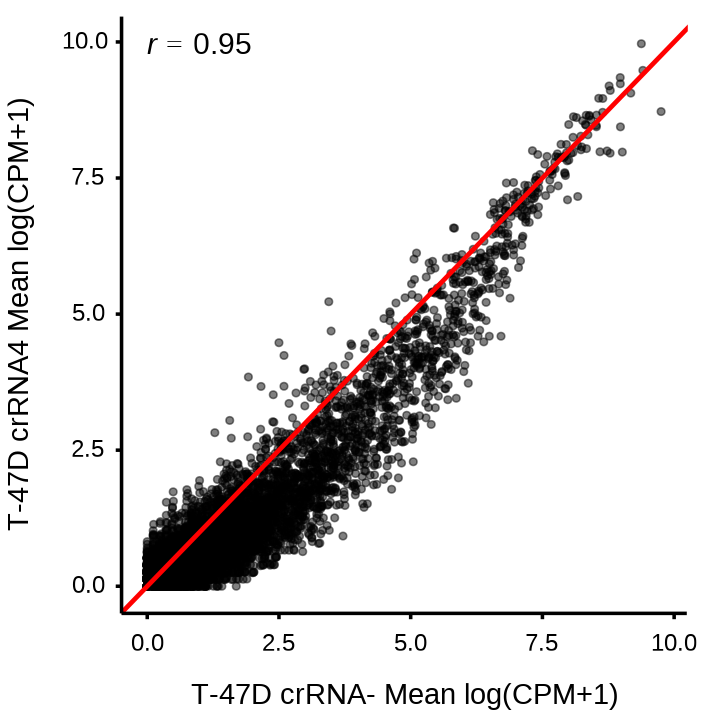

In [6]:
#input
adataA <- subset(adata, sample_group == "T47D_PIKnocrRNA")
adataB <- subset(adata, sample_group == "T47D_PIKcrRNA4")

#get raw count data
exprA <- data.frame(GetAssayData(adataA, layer = "counts"))

exprB <- data.frame(GetAssayData(adataB, layer = "counts"))


#normalise
for (i in rownames(adataA@meta.data)){
    exprA[, i] <- (exprA[, i]/adataA@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprA[, i] <- log1p(exprA[, i]) #natural log
}

for (i in rownames(adataB@meta.data)){
    exprB[, i] <- (exprB[, i]/adataB@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprB[, i] <- log1p(exprB[, i]) #natural log
}

# Calculate average expression for each gene across cells
mean_exprA <- rowMeans(exprA)
mean_exprB <- rowMeans(exprB)

# Keep only common genes
common_genes <- intersect(rownames(exprA), rownames(exprB))

# Build a data frame
df_cor1 <- data.frame(
  gene = common_genes,
  A = mean_exprA[common_genes],
  B = mean_exprB[common_genes]
)


# Plot mean expression correlation
ggplot(df_cor1, aes(x = A, y = B)) +
  geom_point(alpha = 0.5, color = "black") +                     # scatter points
  stat_cor(
  method = "pearson",
  aes(label = paste0("italic(r) == ", round(after_stat(r), 2))),
  label.x = min(df_cor1$A),
  label.y = max(df_cor1$B),
  size = 8,
  parse = TRUE
) +
  geom_abline(size=1, slope = 1, intercept = 0, linetype = "solid",    # optional y=x line
              color = "red") +
  theme_bw(base_size = 14) +
  labs(
    x = "T-47D crRNA- Mean log(CPM+1)",
    y = "T-47D crRNA4 Mean log(CPM+1)"
  ) +
  theme(
    axis.text = element_text(size = 20),
    axis.text.x = element_text(size = 18, vjust = 0, hjust = 0.5, color = "black",), #vjust horizontal justification (1 = right, 0 = left)
    axis.text.y = element_text(size = 18, vjust = 0.4, hjust = 0.75, color = "black",), #hjust vertical justification (0 = bottom, 1 = top)
    axis.title.x = element_text(size = 22, margin = margin(t = 20), color = "black",),  
    axis.title.y = element_text(size = 22, margin = margin(r = 10), color = "black",),  
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.ticks = element_line(size = 0.75, color = "black",),
    plot.margin = margin(t = 10, r = 20, b = 5, l = 5)  # top, right, bottom, left in points
  )

ggsave("data/cor_T47D_no_cr4.pdf", plot = last_plot(), width = 6, height = 6, units = "in", dpi = 300)

Warning message:
“Duplicated aesthetics after name standardisation: parse”


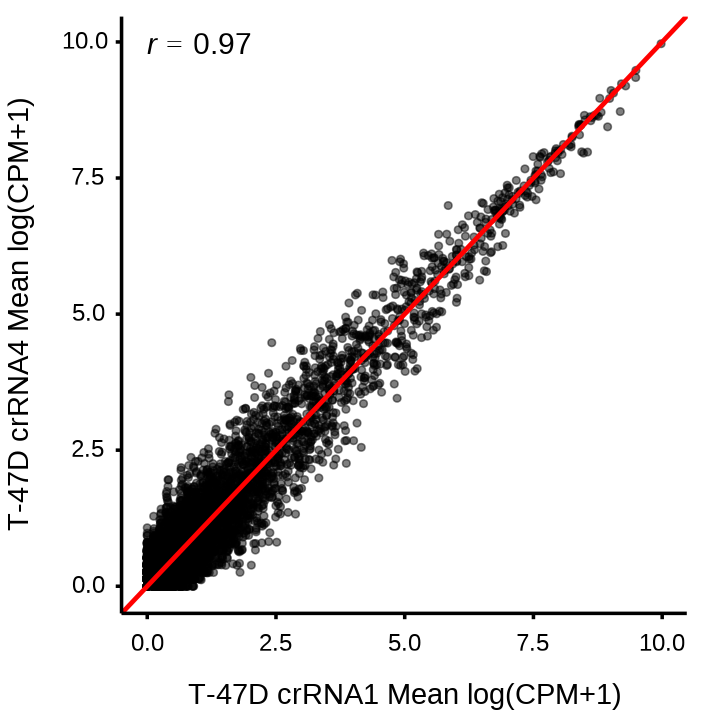

In [7]:
#input
adataA <- subset(adata, sample_group == "T47D_PIKcrRNA1")
adataB <- subset(adata, sample_group == "T47D_PIKcrRNA4")

#get raw count data
exprA <- data.frame(GetAssayData(adataA, layer = "counts"))

exprB <- data.frame(GetAssayData(adataB, layer = "counts"))


#normalise
for (i in rownames(adataA@meta.data)){
    exprA[, i] <- (exprA[, i]/adataA@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprA[, i] <- log1p(exprA[, i]) #natural log
}

for (i in rownames(adataB@meta.data)){
    exprB[, i] <- (exprB[, i]/adataB@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprB[, i] <- log1p(exprB[, i]) #natural log
}

# Calculate average expression for each gene across cells
mean_exprA <- rowMeans(exprA)
mean_exprB <- rowMeans(exprB)

# Keep only common genes
common_genes <- intersect(rownames(exprA), rownames(exprB))

# Build a data frame
df_cor1 <- data.frame(
  gene = common_genes,
  A = mean_exprA[common_genes],
  B = mean_exprB[common_genes]
)


# Plot mean expression correlation
ggplot(df_cor1, aes(x = A, y = B)) +
  geom_point(alpha = 0.5, color = "black") +                     # scatter points
  stat_cor(
  method = "pearson",
  aes(label = paste0("italic(r) == ", round(after_stat(r), 2))),
  label.x = min(df_cor1$A),
  label.y = max(df_cor1$B),
  size = 8,
  parse = TRUE
) +
  geom_abline(size=1, slope = 1, intercept = 0, linetype = "solid",    # optional y=x line
              color = "red") +
  theme_bw(base_size = 14) +
  labs(
    x = "T-47D crRNA1 Mean log(CPM+1)",
    y = "T-47D crRNA4 Mean log(CPM+1)"
  ) +
  theme(
    axis.text = element_text(size = 20),
    axis.text.x = element_text(size = 18, vjust = 0, hjust = 0.5, color = "black",), #vjust horizontal justification (1 = right, 0 = left)
    axis.text.y = element_text(size = 18, vjust = 0.4, hjust = 0.75, color = "black",), #hjust vertical justification (0 = bottom, 1 = top)
    axis.title.x = element_text(size = 22, margin = margin(t = 20), color = "black",),  
    axis.title.y = element_text(size = 22, margin = margin(r = 10), color = "black",),  
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.ticks = element_line(size = 0.75, color = "black",),
    plot.margin = margin(t = 10, r = 20, b = 5, l = 5)  # top, right, bottom, left in points
  )

ggsave("data/cor_T47D_cr1_cr4.pdf", plot = last_plot(), width = 6, height = 6, units = "in", dpi = 300)

In [8]:
#U2OS

Warning message:
“Duplicated aesthetics after name standardisation: parse”


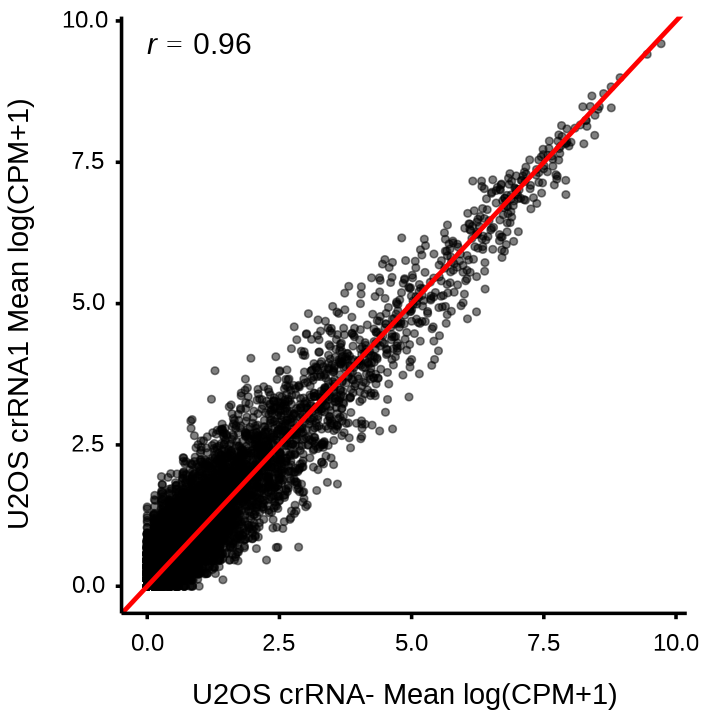

In [9]:
#input
adataA <- subset(adata, sample_group == "U2OS_PIKnocrRNA")
adataB <- subset(adata, sample_group == "U2OS_PIKcrRNA1")

#get raw count data
exprA <- data.frame(GetAssayData(adataA, layer = "counts"))

exprB <- data.frame(GetAssayData(adataB, layer = "counts"))


#normalise
for (i in rownames(adataA@meta.data)){
    exprA[, i] <- (exprA[, i]/adataA@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprA[, i] <- log1p(exprA[, i]) #natural log
}

for (i in rownames(adataB@meta.data)){
    exprB[, i] <- (exprB[, i]/adataB@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprB[, i] <- log1p(exprB[, i]) #natural log
}

# Calculate average expression for each gene across cells
mean_exprA <- rowMeans(exprA)
mean_exprB <- rowMeans(exprB)

# Keep only common genes
common_genes <- intersect(rownames(exprA), rownames(exprB))

# Build a data frame
df_cor1 <- data.frame(
  gene = common_genes,
  A = mean_exprA[common_genes],
  B = mean_exprB[common_genes]
)


# Plot mean expression correlation
ggplot(df_cor1, aes(x = A, y = B)) +
  geom_point(alpha = 0.5, color = "black") +                     # scatter points
  stat_cor(
  method = "pearson",
  aes(label = paste0("italic(r) == ", round(after_stat(r), 2))),
  label.x = min(df_cor1$A),
  label.y = max(df_cor1$B),
  size = 8,
  parse = TRUE
) +
  geom_abline(size=1, slope = 1, intercept = 0, linetype = "solid",    # optional y=x line
              color = "red") +
  theme_bw(base_size = 14) +
  labs(
    x = "U2OS crRNA- Mean log(CPM+1)",
    y = "U2OS crRNA1 Mean log(CPM+1)"
  ) +
  theme(
    axis.text = element_text(size = 20),
    axis.text.x = element_text(size = 18, vjust = 0, hjust = 0.5, color = "black",), #vjust horizontal justification (1 = right, 0 = left)
    axis.text.y = element_text(size = 18, vjust = 0.4, hjust = 0.75, color = "black",), #hjust vertical justification (0 = bottom, 1 = top)
    axis.title.x = element_text(size = 22, margin = margin(t = 20), color = "black",),  
    axis.title.y = element_text(size = 22, margin = margin(r = 10), color = "black",),  
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.ticks = element_line(size = 0.75, color = "black",),
    plot.margin = margin(t = 10, r = 20, b = 5, l = 5)  # top, right, bottom, left in points
  )

ggsave("data/cor_U2OS_no_cr1.pdf", plot = last_plot(), width = 6, height = 6, units = "in", dpi = 300)

Warning message:
“Duplicated aesthetics after name standardisation: parse”


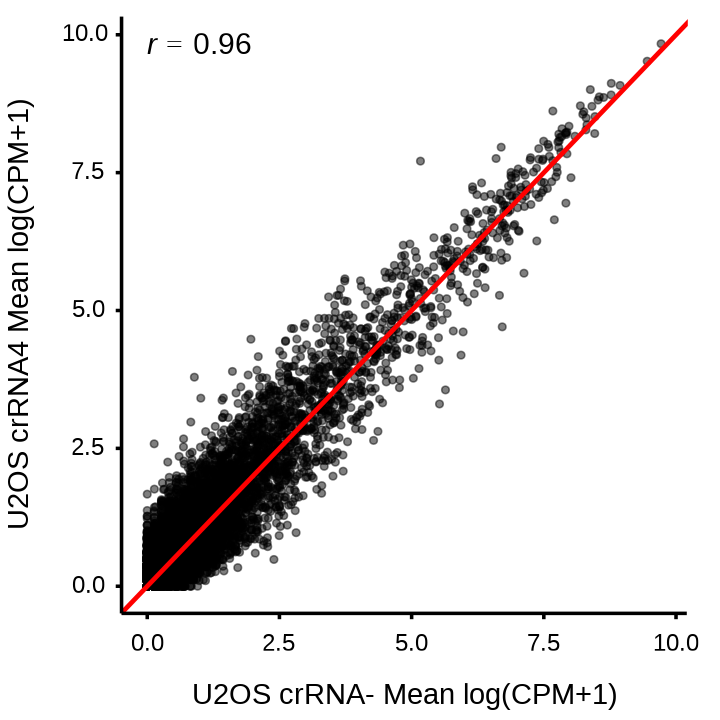

In [10]:
#input
adataA <- subset(adata, sample_group == "U2OS_PIKnocrRNA")
adataB <- subset(adata, sample_group == "U2OS_PIKcrRNA4")

#get raw count data
exprA <- data.frame(GetAssayData(adataA, layer = "counts"))

exprB <- data.frame(GetAssayData(adataB, layer = "counts"))


#normalise
for (i in rownames(adataA@meta.data)){
    exprA[, i] <- (exprA[, i]/adataA@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprA[, i] <- log1p(exprA[, i]) #natural log
}

for (i in rownames(adataB@meta.data)){
    exprB[, i] <- (exprB[, i]/adataB@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprB[, i] <- log1p(exprB[, i]) #natural log
}

# Calculate average expression for each gene across cells
mean_exprA <- rowMeans(exprA)
mean_exprB <- rowMeans(exprB)

# Keep only common genes
common_genes <- intersect(rownames(exprA), rownames(exprB))

# Build a data frame
df_cor1 <- data.frame(
  gene = common_genes,
  A = mean_exprA[common_genes],
  B = mean_exprB[common_genes]
)


# Plot mean expression correlation
ggplot(df_cor1, aes(x = A, y = B)) +
  geom_point(alpha = 0.5, color = "black") +                     # scatter points
  stat_cor(
  method = "pearson",
  aes(label = paste0("italic(r) == ", round(after_stat(r), 2))),
  label.x = min(df_cor1$A),
  label.y = max(df_cor1$B),
  size = 8,
  parse = TRUE
) +
  geom_abline(size=1, slope = 1, intercept = 0, linetype = "solid",    # optional y=x line
              color = "red") +
  theme_bw(base_size = 14) +
  labs(
    x = "U2OS crRNA- Mean log(CPM+1)",
    y = "U2OS crRNA4 Mean log(CPM+1)"
  ) +
  theme(
    axis.text = element_text(size = 20),
    axis.text.x = element_text(size = 18, vjust = 0, hjust = 0.5, color = "black",), #vjust horizontal justification (1 = right, 0 = left)
    axis.text.y = element_text(size = 18, vjust = 0.4, hjust = 0.75, color = "black",), #hjust vertical justification (0 = bottom, 1 = top)
    axis.title.x = element_text(size = 22, margin = margin(t = 20), color = "black",),  
    axis.title.y = element_text(size = 22, margin = margin(r = 10), color = "black",),  
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.ticks = element_line(size = 0.75, color = "black",),
    plot.margin = margin(t = 10, r = 20, b = 5, l = 5)  # top, right, bottom, left in points
  )

ggsave("data/cor_U2OS_no_cr4.pdf", plot = last_plot(), width = 6, height = 6, units = "in", dpi = 300)

Warning message:
“Duplicated aesthetics after name standardisation: parse”


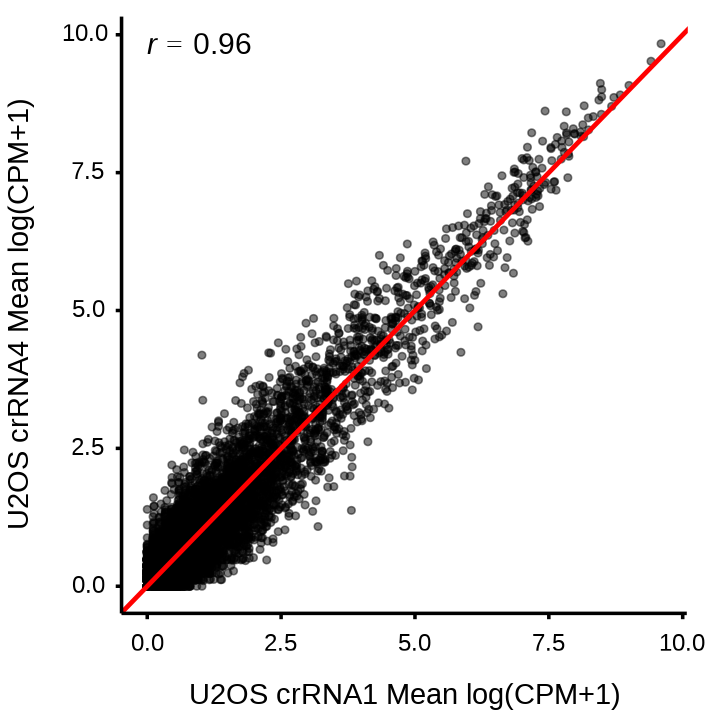

In [11]:
#input
adataA <- subset(adata, sample_group == "U2OS_PIKcrRNA1")
adataB <- subset(adata, sample_group == "U2OS_PIKcrRNA4")

#get raw count data
exprA <- data.frame(GetAssayData(adataA, layer = "counts"))

exprB <- data.frame(GetAssayData(adataB, layer = "counts"))


#normalise
for (i in rownames(adataA@meta.data)){
    exprA[, i] <- (exprA[, i]/adataA@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprA[, i] <- log1p(exprA[, i]) #natural log
}

for (i in rownames(adataB@meta.data)){
    exprB[, i] <- (exprB[, i]/adataB@meta.data[i, "nCount_RNA"])*10^6 #CPM
    exprB[, i] <- log1p(exprB[, i]) #natural log
}

# Calculate average expression for each gene across cells
mean_exprA <- rowMeans(exprA)
mean_exprB <- rowMeans(exprB)

# Keep only common genes
common_genes <- intersect(rownames(exprA), rownames(exprB))

# Build a data frame
df_cor1 <- data.frame(
  gene = common_genes,
  A = mean_exprA[common_genes],
  B = mean_exprB[common_genes]
)


# Plot mean expression correlation
ggplot(df_cor1, aes(x = A, y = B)) +
  geom_point(alpha = 0.5, color = "black") +                     # scatter points
  stat_cor(
  method = "pearson",
  aes(label = paste0("italic(r) == ", round(after_stat(r), 2))),
  label.x = min(df_cor1$A),
  label.y = max(df_cor1$B),
  size = 8,
  parse = TRUE
) +
  geom_abline(size=1, slope = 1, intercept = 0, linetype = "solid",    # optional y=x line
              color = "red") +
  theme_bw(base_size = 14) +
  labs(
    x = "U2OS crRNA1 Mean log(CPM+1)",
    y = "U2OS crRNA4 Mean log(CPM+1)"
  ) +
  theme(
    axis.text = element_text(size = 20),
    axis.text.x = element_text(size = 18, vjust = 0, hjust = 0.5, color = "black",), #vjust horizontal justification (1 = right, 0 = left)
    axis.text.y = element_text(size = 18, vjust = 0.4, hjust = 0.75, color = "black",), #hjust vertical justification (0 = bottom, 1 = top)
    axis.title.x = element_text(size = 22, margin = margin(t = 20), color = "black",),  
    axis.title.y = element_text(size = 22, margin = margin(r = 10), color = "black",),  
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.ticks = element_line(size = 0.75, color = "black",),
    plot.margin = margin(t = 10, r = 20, b = 5, l = 5)  # top, right, bottom, left in points
  )
ggsave("data/cor_U2OS_cr1_cr4.pdf", plot = last_plot(), width = 6, height = 6, units = "in", dpi = 300)

In [12]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] showtext_0.9-7     showtextdb_3.0     sysfonts_0.8.9     ggpubr_0.6.1      
 [5] Matrix_1.6-5       lubridate_1.9.4    forcats_1.0.0      purrr_1.1.0       
 [9] readr_2.1.5        tidyr_1.3.1        tibble_3.3.0       tidyverse_2.0.0   
[13] dplyr_1.1.4        Seurat_5.3.0       SeuratObject_5.2.0 sp_2.2-